<a href="https://colab.research.google.com/github/cs24dse016-design/CSL701-CS43_Machine-Learning-Lab/blob/main/Experiments/ML_Experiment_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Student Name :Khushi Harishchandra Pawar

Batch :CS3


Roll Number :CSE43

### **Aim**

To implement graph-based clustering using Minimum Spanning Tree (MST) on the Breast Cancer Wisconsin (Diagnostic) dataset in Python and visualize the resulting clusters.

## Objectives

1. To understand the concept of graph-based clustering and Minimum Spanning Trees (MST).
2. To load and preprocess the Breast Cancer Wisconsin dataset (scaling features and handling metadata).
3. To construct a distance graph from tumor feature representations using Euclidean distance.
4. To compute the Minimum Spanning Tree using Prim's or Kruskal's algorithm (or via scipy/networkx).
5. To form $K=2$ clusters (Malignant vs. Benign) by removing the single ($K - 1$) largest edge weight from the MST.
6. To evaluate the performance of the MST-based clustering model using evaluation metrics.

# Relevant Theory

###Graph-Based Clustering & Minimum Spanning Tree (MST)
Graph-based clustering represents data points as nodes in a graph, with edges representing relationships or distance metrics between individual samples.
* **Complete Graph Construction**: Given a dataset $X = \{x_1, x_2, \dots, x_n\}$,
each tissue sample is treated as a vertex. An edge weight $w(i, j)$ corresponds to the distance between sample $i$ and sample $j$ (typically Euclidean distance on scaled features):$$w(i, j) = \Vert{}x_i - x_j\Vert{}_2$$
* **Minimum Spanning Tree (MST)**: An MST is a subset of edges connecting all vertices in the graph without forming any cycles, while minimizing the total edge weight sum.
* **MST-Based Clustering Method**:
  1. Construct a fully connected graph with pairwise edge weights across standardized features.
  2. Compute the Minimum Spanning Tree (MST).
  3. To partition the data into $K$ distinct clusters (such as Malignant and Benign groups), identify and remove the $K - 1$ largest (most expensive) edges from the MST.4. The resulting disconnected subgraphs represent the separate data clusters.
### Dataset Information
Get the Breast Cancer Wisconsin (Diagnostic) dataset from Kaggle or via scikit-learn (load_breast_cancer).
The dataset contains key cell nuclei features computed from digitized images of fine needle aspirates (FNA) of breast masses:
  * Total Instances: 569 samples
  * Target Classes: Malignant (M) and Benign (B)* Feature Attributes: 30 numerical features (e.g., mean radius, mean texture, mean perimeter, mean area, mean smoothness)

For 2D visualization, two key features (such as mean radius and mean texture) will be selected.

# Task 1: Import Libraries and Load Dataset

* Import required libraries (numpy, pandas, matplotlib, scipy, networkx, sklearn).

* Load the Breast Cancer dataset using below link from Kaggle.

  https://www.kaggle.com/datasets/utkarshx27/breast-cancer-wisconsin-diagnostic-dataset

---

In [ ]:
# ============================================================
# TASK 1: IMPORT LIBRARIES AND LOAD DATASET
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import networkx as nx

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

from scipy.spatial.distance import pdist, squareform
from scipy.sparse.csgraph import minimum_spanning_tree

# Load dataset
df = pd.read_csv("brca.csv")

# Display first 5 rows
print("First 5 rows of the dataset:")
display(df.head())

# Display shape
print("\nDataset Shape:")
print(df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())

First 5 rows of the dataset:


,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
0,1,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
1,2,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
2,3,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
3,4,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
4,5,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B



Dataset Shape:
(569, 32)

Column Names:
['Unnamed: 0', 'x.radius_mean', 'x.texture_mean', 'x.perimeter_mean', 'x.area_mean', 'x.smoothness_mean', 'x.compactness_mean', 'x.concavity_mean', 'x.concave_pts_mean', 'x.symmetry_mean', 'x.fractal_dim_mean', 'x.radius_se', 'x.texture_se', 'x.perimeter_se', 'x.area_se', 'x.smoothness_se', 'x.compactness_se', 'x.concavity_se', 'x.concave_pts_se', 'x.symmetry_se', 'x.fractal_dim_se', 'x.radius_worst', 'x.texture_worst', 'x.perimeter_worst', 'x.area_worst', 'x.smoothness_worst', 'x.compactness_worst', 'x.concavity_worst', 'x.concave_pts_worst', 'x.symmetry_worst', 'x.fractal_dim_worst', 'y']


# Task 2: Explore the Dataset

* Display missing value checks, summary statistics, and feature dimensions.

* Check the diagnosis class distribution (Malignant vs. Benign).

In [ ]:
# ============================================================
# TASK 2: EXPLORE THE DATASET
# ============================================================

# Column names
print("Column Names:")
print(df.columns.tolist())

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Summary statistics
print("\nSummary Statistics:")
display(df.describe())

# Dataset dimensions
print("\nDataset Dimensions:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# Display data types
print("\nData Types:")
print(df.dtypes)

# Find target column
target_col = None

for col in df.columns:
    if col.strip().lower() in ["y", "diagnosis"]:
        target_col = col
        break

print("\nTarget Column:", target_col)

# Class distribution
if target_col is not None:
    print("\nClass Distribution:")
    print(df[target_col].value_counts())

    print("\nClass Percentage:")
    print(df[target_col].value_counts(normalize=True) * 100)

Column Names:
['Unnamed: 0', 'x.radius_mean', 'x.texture_mean', 'x.perimeter_mean', 'x.area_mean', 'x.smoothness_mean', 'x.compactness_mean', 'x.concavity_mean', 'x.concave_pts_mean', 'x.symmetry_mean', 'x.fractal_dim_mean', 'x.radius_se', 'x.texture_se', 'x.perimeter_se', 'x.area_se', 'x.smoothness_se', 'x.compactness_se', 'x.concavity_se', 'x.concave_pts_se', 'x.symmetry_se', 'x.fractal_dim_se', 'x.radius_worst', 'x.texture_worst', 'x.perimeter_worst', 'x.area_worst', 'x.smoothness_worst', 'x.compactness_worst', 'x.concavity_worst', 'x.concave_pts_worst', 'x.symmetry_worst', 'x.fractal_dim_worst', 'y']

Missing Values:
Unnamed: 0             0
x.radius_mean          0
x.texture_mean         0
x.perimeter_mean       0
x.area_mean            0
x.smoothness_mean      0
x.compactness_mean     0
x.concavity_mean       0
x.concave_pts_mean     0
x.symmetry_mean        0
x.fractal_dim_mean     0
x.radius_se            0
x.texture_se           0
x.perimeter_se         0
x.area_se            

,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,...,x.radius_worst,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,285.000000,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,164.400426,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,1.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,143.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,285.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,427.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,569.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500



Dataset Dimensions:
Rows: 569
Columns: 32

Data Types:
Unnamed: 0               int64
x.radius_mean          float64
x.texture_mean         float64
x.perimeter_mean       float64
x.area_mean            float64
x.smoothness_mean      float64
x.compactness_mean     float64
x.concavity_mean       float64
x.concave_pts_mean     float64
x.symmetry_mean        float64
x.fractal_dim_mean     float64
x.radius_se            float64
x.texture_se           float64
x.perimeter_se         float64
x.area_se              float64
x.smoothness_se        float64
x.compactness_se       float64
x.concavity_se         float64
x.concave_pts_se       float64
x.symmetry_se          float64
x.fractal_dim_se       float64
x.radius_worst         float64
x.texture_worst        float64
x.perimeter_worst      float64
x.area_worst           float64
x.smoothness_worst     float64
x.compactness_worst    float64
x.concavity_worst      float64
x.concave_pts_worst    float64
x.symmetry_worst       float64
x.fractal_dim_

# Task 3: Preprocess and Scale Features

* Select numerical features and drop non-informative identifiers (such as id).

* Apply StandardScaler to normalize feature magnitudes prior to graph distance calculation.

In [ ]:
# ============================================================
# TASK 3: PREPROCESS AND SCALE FEATURES
# ============================================================

# Select numerical columns
X = df.select_dtypes(include=["int64", "float64"]).copy()

# Remove ID column if present
if "id" in X.columns:
    X = X.drop(columns=["id"])

# Remove unnamed index column
if "Unnamed: 0" in X.columns:
    X = X.drop(columns=["Unnamed: 0"])

# Remove target column if it is numerical
if target_col is not None and target_col in X.columns:
    X = X.drop(columns=[target_col])

# Apply StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert to DataFrame
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

print("Original Feature Shape:", X.shape)
print("Scaled Feature Shape:", X_scaled.shape)

print("\nFirst 5 rows after scaling:")
display(X_scaled.head())

Original Feature Shape: (569, 30)
Scaled Feature Shape: (569, 30)

First 5 rows after scaling:


,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,x.fractal_dim_mean,...,x.radius_worst,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst
0,-0.166799,-1.147162,-0.185728,-0.251957,0.101747,-0.436850,-0.278210,-0.028609,0.267911,-0.728310,...,-0.240048,-1.045005,-0.225217,-0.297761,0.509873,-0.489605,-0.159223,0.216123,0.123347,-0.629292
1,-0.297446,-0.833008,-0.261106,-0.383638,0.792763,0.429422,-0.541362,-0.459627,0.567289,0.753087,...,-0.366368,-0.844707,-0.332744,-0.439624,-0.051226,0.148443,-0.399099,-0.636110,0.458227,-0.117250
2,-1.313080,-1.593959,-1.302806,-1.083572,0.429819,-0.747086,-0.743748,-0.726337,0.012345,0.886341,...,-1.250611,-1.631243,-1.254913,-0.994422,0.001377,-0.887193,-0.880434,-0.796903,-0.729224,-0.344455
3,-0.311646,-0.202373,-0.385500,-0.372831,-0.464730,-1.263703,-0.793214,-0.507861,-1.258183,-0.590802,...,-0.614867,-0.466909,-0.679153,-0.588344,-1.549975,-1.323648,-1.073966,-0.981753,-1.478256,-1.233324
4,-1.684571,-0.570050,-1.658278,-1.288347,-0.737294,-0.851130,-0.915500,-1.109197,-0.155598,0.316465,...,-1.512777,-0.605327,-1.489328,-1.122222,-0.116980,-0.754239,-0.975761,-1.354653,0.330422,-0.546168


# Task 4: Construct Pairwise Distance Matrix & Graph

* Compute pairwise Euclidean distance matrix across all scaled samples using scipy.spatial.distance.pdist or cdist.

* Represent the dataset as a weighted complete graph.

In [ ]:
# ============================================================
# TASK 4: CONSTRUCT PAIRWISE DISTANCE MATRIX AND GRAPH
# ============================================================

# Calculate pairwise Euclidean distances
distance_vector = pdist(
    X_scaled,
    metric="euclidean"
)

# Convert to square distance matrix
distance_matrix = squareform(distance_vector)

print("Distance Matrix Shape:")
print(distance_matrix.shape)

print("\nFirst 5 x 5 Distance Matrix:")
print(distance_matrix[:5, :5])

# Create weighted complete graph
G = nx.Graph()

# Add all nodes
n = len(X_scaled)

for i in range(n):
    G.add_node(i)

# Add weighted edges
for i in range(n):
    for j in range(i + 1, n):
        G.add_edge(
            i,
            j,
            weight=distance_matrix[i, j]
        )

print("\nNumber of Nodes:")
print(G.number_of_nodes())

print("\nNumber of Edges:")
print(G.number_of_edges())

Distance Matrix Shape:
(569, 569)

First 5 x 5 Distance Matrix:
[[0.         3.10724668 3.62314178 5.20448164 4.46708561]
 [3.10724668 0.         4.01027585 5.62302017 4.37098277]
 [3.62314178 4.01027585 0.         5.12193591 2.94839575]
 [5.20448164 5.62302017 5.12193591 0.         5.02798792]
 [4.46708561 4.37098277 2.94839575 5.02798792 0.        ]]

Number of Nodes:
569

Number of Edges:
161596


# Task 5: Compute the Minimum Spanning Tree (MST)

* Compute the MST using scipy.sparse.csgraph.minimum_spanning_tree or networkx.minimum_spanning_tree.

* Extract the resulting graph connections and weights.

In [ ]:
# ============================================================
# TASK 5: COMPUTE MINIMUM SPANNING TREE (MST)
# ============================================================

# Compute MST
mst_sparse = minimum_spanning_tree(distance_matrix)

# Convert sparse matrix to NumPy array
mst_matrix = mst_sparse.toarray()

# Create NetworkX graph
MST = nx.from_numpy_array(mst_matrix)

# Remove zero-weight edges
MST.remove_edges_from(
    [
        (u, v)
        for u, v, d in MST.edges(data=True)
        if d["weight"] == 0
    ]
)

# Display MST connections
print("MST Connections and Weights:")

for u, v, data in MST.edges(data=True):
    print(
        f"Node {u} -- Node {v} : "
        f"Weight = {data['weight']:.3f}"
    )

print("\nNumber of MST Nodes:")
print(MST.number_of_nodes())

print("\nNumber of MST Edges:")
print(MST.number_of_edges())

MST Connections and Weights:
Node 0 -- Node 81 : Weight = 1.689
Node 0 -- Node 108 : Weight = 2.171
Node 1 -- Node 105 : Weight = 1.661
Node 2 -- Node 70 : Weight = 2.219
Node 3 -- Node 170 : Weight = 2.346
Node 3 -- Node 222 : Weight = 2.542
Node 4 -- Node 84 : Weight = 2.166
Node 4 -- Node 279 : Weight = 1.860
Node 5 -- Node 125 : Weight = 1.766
Node 5 -- Node 172 : Weight = 2.017
Node 6 -- Node 336 : Weight = 1.420
Node 6 -- Node 393 : Weight = 1.693
Node 7 -- Node 140 : Weight = 1.773
Node 8 -- Node 66 : Weight = 1.511
Node 9 -- Node 95 : Weight = 1.673
Node 9 -- Node 126 : Weight = 1.576
Node 9 -- Node 192 : Weight = 1.626
Node 10 -- Node 126 : Weight = 1.778
Node 11 -- Node 140 : Weight = 1.325
Node 11 -- Node 192 : Weight = 1.840
Node 12 -- Node 322 : Weight = 1.996
Node 13 -- Node 191 : Weight = 3.198
Node 13 -- Node 247 : Weight = 3.246
Node 14 -- Node 16 : Weight = 2.746
Node 15 -- Node 103 : Weight = 3.631
Node 16 -- Node 24 : Weight = 1.768
Node 16 -- Node 182 : Weight = 2.

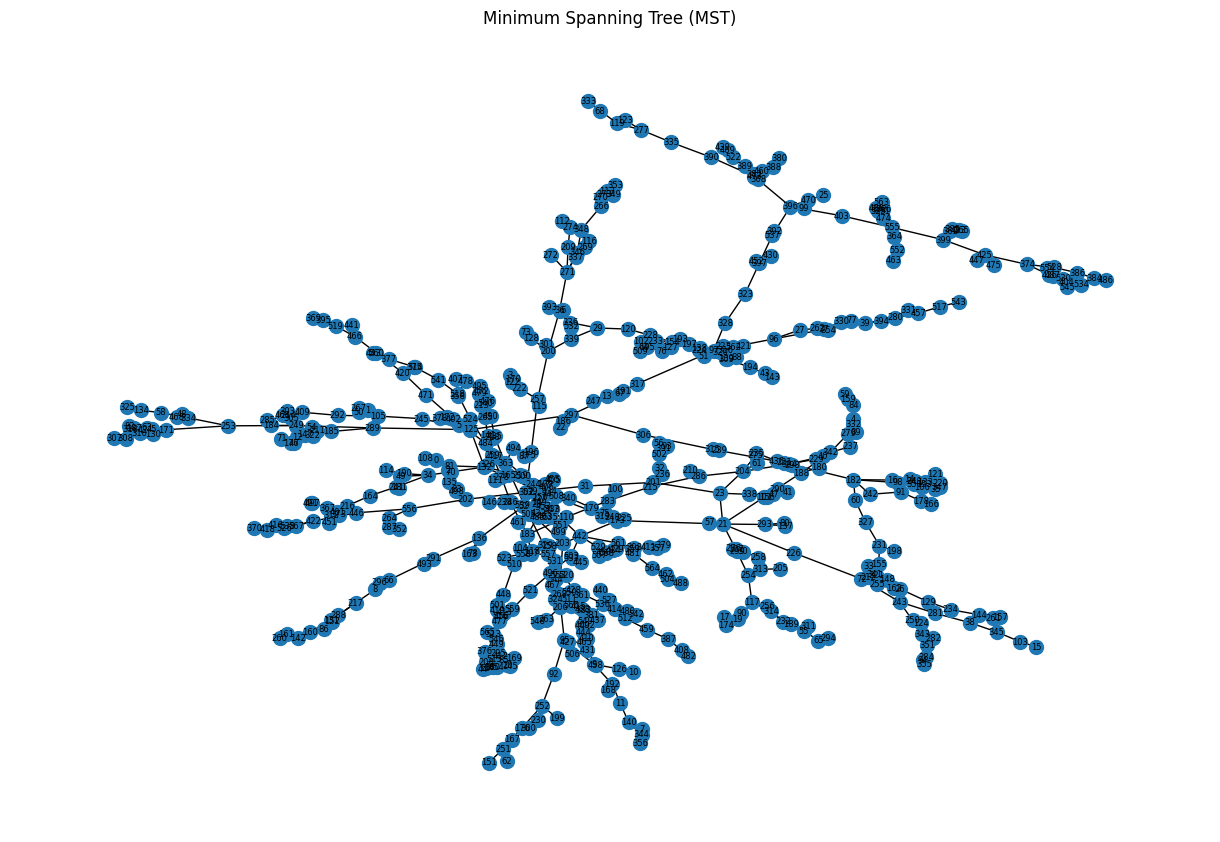

In [ ]:
# ============================================================
# VISUALIZE MST
# ============================================================

plt.figure(figsize=(12, 8))

pos = nx.spring_layout(MST, seed=42)

nx.draw(
    MST,
    pos,
    with_labels=True,
    node_size=100,
    font_size=6
)

plt.title("Minimum Spanning Tree (MST)")
plt.show()

# Task 6: Implement Graph-Based Clustering ($K=2$)

* Sort the edges of the MST in descending order by edge weight.
* Remove the largest $K - 1$ edge (1 largest edge for 2 clusters) to split the MST into 2 connected components.
* Assign final cluster labels based on the resulting component indices.


In [ ]:
# ============================================================
# TASK 6: FORM K = 2 CLUSTERS
# ============================================================

# Make a copy of MST
cluster_graph = MST.copy()

# Find the largest edge
largest_edge = max(
    cluster_graph.edges(data=True),
    key=lambda x: x[2]["weight"]
)

u, v, data = largest_edge

print(
    "Largest MST Edge:"
    f"\nNode {u} -- Node {v}"
    f" : Weight = {data['weight']:.3f}"
)

# Remove largest edge
cluster_graph.remove_edge(u, v)

# Find connected components
components = list(
    nx.connected_components(cluster_graph)
)

print("\nNumber of Clusters:")
print(len(components))

# Assign cluster labels
cluster_labels = np.zeros(
    len(X_scaled),
    dtype=int
)

for cluster_id, component in enumerate(components):
    for node in component:
        cluster_labels[node] = cluster_id

# Display cluster sizes
print("\nCluster Sizes:")

for cluster_id in range(len(components)):
    size = np.sum(cluster_labels == cluster_id)

    print(
        f"Cluster {cluster_id}: "
        f"{size} samples"
    )

# Display first 20 labels
print("\nFirst 20 Cluster Labels:")
print(cluster_labels[:20])

Largest MST Edge:
Node 544 -- Node 553 : Weight = 12.300

Number of Clusters:
2

Cluster Sizes:
Cluster 0: 567 samples
Cluster 1: 2 samples

First 20 Cluster Labels:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


# Task 7: valuate MST Clustering Performance

Evaluate cluster assignment against ground truth labels using:

  *  Silhouette Score

  *  Adjusted Rand Index (ARI)

  *  Normalized Mutual Information (NMI)

In [ ]:
# ============================================================
# TASK 7: EVALUATE MST CLUSTERING PERFORMANCE
# ============================================================

from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

# Silhouette Score
sil_score = silhouette_score(
    X_scaled,
    cluster_labels
)

print(
    "Silhouette Score:",
    round(sil_score, 4)
)

# Ground truth labels
if target_col is not None:

    y_true = (
        df[target_col]
        .astype(str)
        .str.strip()
        .str.upper()
    )

    # Convert B/M or other labels to numerical values
    unique_labels = y_true.unique()

    if set(unique_labels).issubset({"B", "M"}):
        y_true = y_true.map({
            "B": 0,
            "M": 1
        })
    else:
        y_true = pd.factorize(y_true)[0]

    # ARI
    ari_score = adjusted_rand_score(
        y_true,
        cluster_labels
    )

    # NMI
    nmi_score = normalized_mutual_info_score(
        y_true,
        cluster_labels
    )

    print(
        "Adjusted Rand Index (ARI):",
        round(ari_score, 4)
    )

    print(
        "Normalized Mutual Information (NMI):",
        round(nmi_score, 4)
    )

Silhouette Score: 0.6607
Adjusted Rand Index (ARI): 0.0048
Normalized Mutual Information (NMI): 0.0102


# Task 8: Visualize MST and Graph-Based Clusters

* Select two representative features (e.g., mean radius vs. mean texture) for 2D plotting.
 * Plot 1: Unclustered standardized data points.
* Plot 2: Minimum Spanning Tree (MST) edge connections overlaid on the data.
* Plot 3: Final clusters formed after cutting the $K - 1$ largest edge(s).

Feature 1: x.radius_mean
Feature 2: x.texture_mean


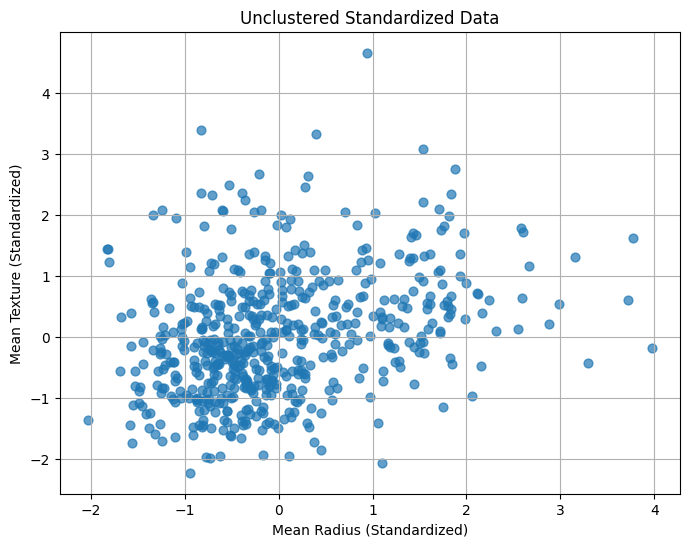

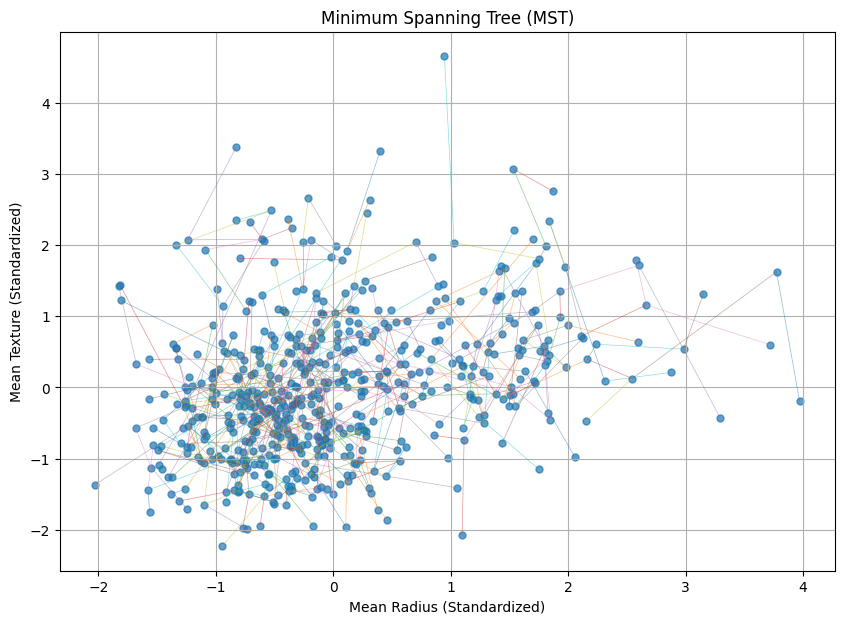

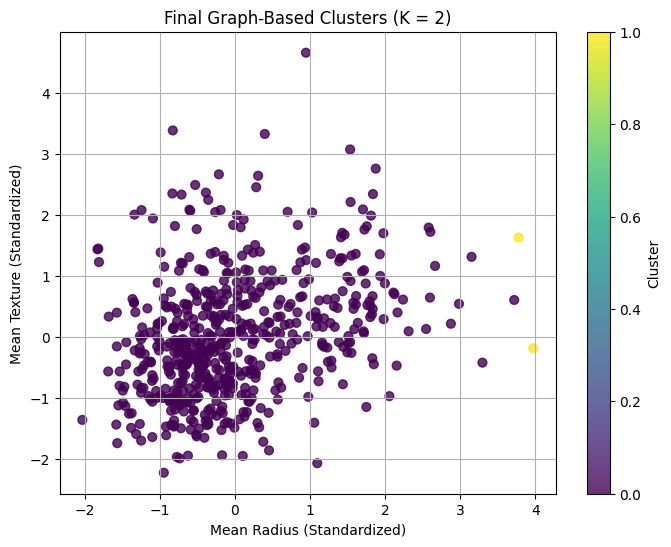

In [ ]:
# ============================================================
# TASK 8: VISUALIZE MST AND GRAPH-BASED CLUSTERS
# ============================================================

# Find Mean Radius column
radius_col = next(
    (
        col for col in X.columns
        if "radius" in col.lower()
        and "mean" in col.lower()
    ),
    X.columns[0]
)

# Find Mean Texture column
texture_col = next(
    (
        col for col in X.columns
        if "texture" in col.lower()
        and "mean" in col.lower()
    ),
    X.columns[1]
)

# Get feature positions
radius_index = list(X.columns).index(
    radius_col
)

texture_index = list(X.columns).index(
    texture_col
)

# Standardized values
x_axis = X_scaled.iloc[
    :, radius_index
]

y_axis = X_scaled.iloc[
    :, texture_index
]

print("Feature 1:", radius_col)
print("Feature 2:", texture_col)


# ------------------------------------------------------------
# PLOT 1: UNCLUSTERED DATA
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    x_axis,
    y_axis,
    s=40,
    alpha=0.7
)

plt.xlabel(
    "Mean Radius (Standardized)"
)

plt.ylabel(
    "Mean Texture (Standardized)"
)

plt.title(
    "Unclustered Standardized Data"
)

plt.grid(True)

plt.show()


# ------------------------------------------------------------
# PLOT 2: MST EDGE CONNECTIONS
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

plt.scatter(
    x_axis,
    y_axis,
    s=25,
    alpha=0.7
)

# Draw MST edges
for u, v, data in MST.edges(data=True):

    plt.plot(
        [x_axis.iloc[u], x_axis.iloc[v]],
        [y_axis.iloc[u], y_axis.iloc[v]],
        linewidth=0.5,
        alpha=0.5
    )

plt.xlabel(
    "Mean Radius (Standardized)"
)

plt.ylabel(
    "Mean Texture (Standardized)"
)

plt.title(
    "Minimum Spanning Tree (MST)"
)

plt.grid(True)

plt.show()


# ------------------------------------------------------------
# PLOT 3: FINAL GRAPH-BASED CLUSTERS
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    x_axis,
    y_axis,
    c=cluster_labels,
    cmap="viridis",
    s=40,
    alpha=0.8
)

plt.xlabel(
    "Mean Radius (Standardized)"
)

plt.ylabel(
    "Mean Texture (Standardized)"
)

plt.title(
    "Final Graph-Based Clusters (K = 2)"
)

plt.colorbar(
    label="Cluster"
)

plt.grid(True)

plt.show()

# Conclusion

The experiment successfully demonstrated the implementation of Graph-Based Clustering using a Minimum Spanning Tree (MST) on the Breast Cancer Wisconsin (Diagnostic) dataset. The dataset was preprocessed, cleaned, and standardized before computing pairwise distances. The MST was generated, and by removing the largest edge(s), clusters representing tumor categories were obtained, evaluated using clustering metrics, and visualized.